<div style="
    background: linear-gradient(135deg, #12002F, #2D0B59);
    border-radius: 18px;
    padding: 28px;
    color: white;
    text-align: center;
    margin: 20px 0;
    border: 1px solid #C026FF;
    box-shadow: 0 0 18px #C026FF;
">

<div style="
    font-size: 13px;
    letter-spacing: 2px;
    font-weight: 700;
    color: #F0ABFC;
">
HANDS-ON LAB
</div>

<div style="
    font-size: 30px;
    font-weight: 800;
    margin-top: 10px;
    text-shadow: 0 0 12px #C026FF;
">
🧪 Comparing Clustering Methods
</div>

<div style="
    font-size: 17px;
    margin-top: 10px;
    color: #E9D5FF;
">
Day 2 • DBSCAN & Hierarchical Clustering
</div>

<div style="
    margin-top: 18px;
    display: inline-block;
    background: #7E22CE;
    padding: 9px 20px;
    border-radius: 20px;
    font-size: 13px;
    font-weight: 700;
    box-shadow: 0 0 10px #A855F7;
">
K-MEANS • DBSCAN • HIERARCHICAL
</div>

</div>

<div style="
    background: linear-gradient(135deg, #12002F, #2D0B59);
    border-radius: 14px;
    padding: 20px;
    color: white;
    border: 1px solid #C026FF;
    box-shadow: 0 0 12px #C026FF;
">

<h2 style="
    color: #F0ABFC;
    font-size: 24px;
    margin: 0 0 10px 0;
    text-shadow: 0 0 8px #C026FF;
">
🔵 Step 1 — Run DBSCAN
</h2>

<p style="
    color: #E9D5FF;
    font-size: 17px;
    line-height: 1.8;
">
We will apply DBSCAN to the same dataset used in the previous clustering task.
DBSCAN groups points based on density and identifies points that do not belong
to dense regions as noise or outliers.
</p>

<p style="
    color: #F0ABFC;
    font-size: 16px;
    line-height: 1.8;
">
🎯 Goal: determine how many clusters DBSCAN finds and how many points are
classified as noise.
</p>

</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [3]:
# Load the dataset

df = pd.read_csv("cluster_moons.csv")

X = df[["X1", "X2"]]

print("Dataset shape:", X.shape)
display(X.head())

Dataset shape: (1500, 2)


,X1,X2
0,0.674362,-0.444625
1,1.547129,-0.239796
2,1.601930,-0.230792
3,0.014563,0.449752
4,1.503476,-0.389164


In [4]:
# Apply DBSCAN

dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X)

# Add cluster labels to the dataframe
df["DBSCAN_Cluster"] = dbscan_labels

# Count clusters and noise points
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 2
Number of noise points: 0


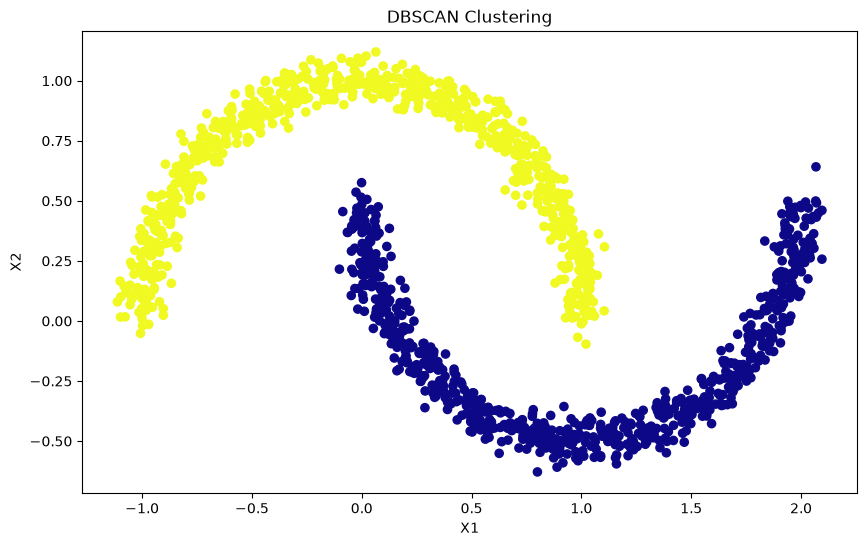

In [5]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X["X1"],
    X["X2"],
    c=dbscan_labels,
    cmap="plasma",
    s=35
)

plt.title("DBSCAN Clustering")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

<div style="
    background: linear-gradient(135deg, #12002F, #2D0B59);
    border-radius: 14px;
    padding: 20px;
    color: white;
    border: 1px solid #C026FF;
    box-shadow: 0 0 12px #C026FF;
">

<h2 style="
    color: #F0ABFC;
    font-size: 24px;
    margin: 0 0 10px 0;
    text-shadow: 0 0 8px #C026FF;
">
🌳 Step 2 — Hierarchical Clustering
</h2>

<p style="
    color: #E9D5FF;
    font-size: 17px;
    line-height: 1.8;
">
We will build a hierarchical clustering model and visualize its structure
using a dendrogram. The dendrogram helps us understand how observations
are gradually merged into larger clusters.
</p>

<p style="
    color: #F0ABFC;
    font-size: 16px;
">
🎯 Goal: create the dendrogram and choose a cut that produces meaningful clusters.
</p>

</div>

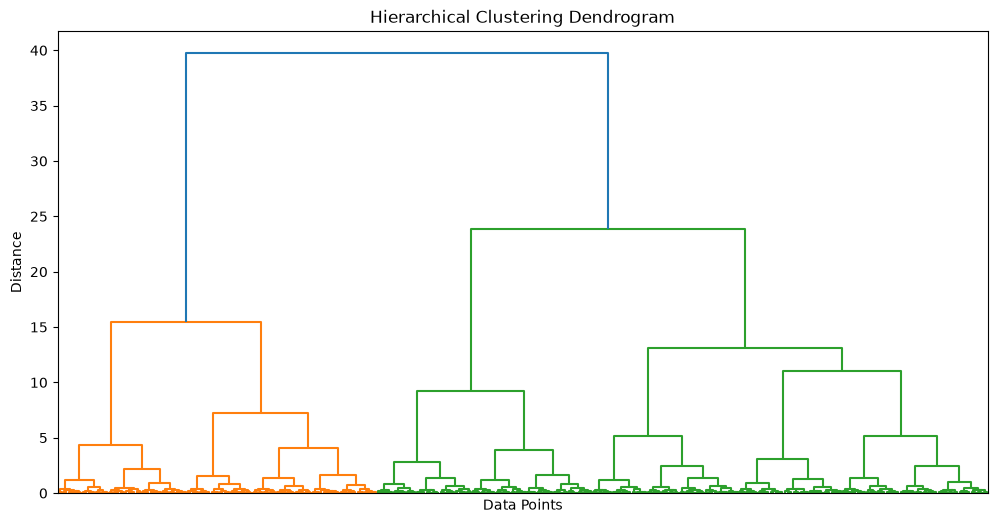

In [6]:
# Create hierarchical linkage

Z = linkage(
    X,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    no_labels=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [7]:
# Choose the number of clusters from the dendrogram

hierarchical_labels = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

df["Hierarchical_Cluster"] = hierarchical_labels

print(
    "Number of hierarchical clusters:",
    len(np.unique(hierarchical_labels))
)

Number of hierarchical clusters: 2


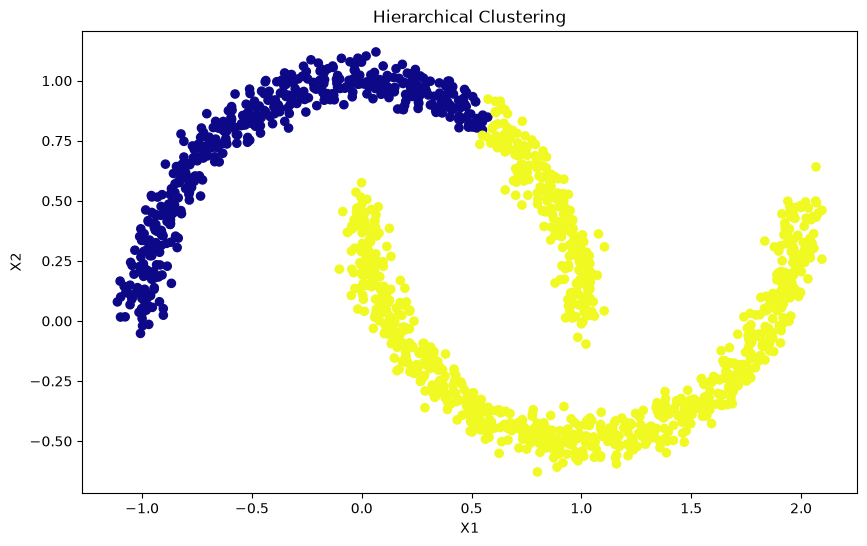

In [8]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X["X1"],
    X["X2"],
    c=hierarchical_labels,
    cmap="plasma",
    s=35
)

plt.title("Hierarchical Clustering")
plt.xlabel("X1")
plt.ylabel("X2")

plt.show()

<div style="
    background: linear-gradient(135deg, #12002F, #2D0B59);
    border-radius: 14px;
    padding: 20px;
    color: white;
    border: 1px solid #C026FF;
    box-shadow: 0 0 12px #C026FF;
">

<h2 style="
    color: #F0ABFC;
    font-size: 24px;
    margin: 0 0 10px 0;
    text-shadow: 0 0 8px #C026FF;
">
⚖️ Step 3 — Compare the Clustering Methods
</h2>

<p style="
    color: #E9D5FF;
    font-size: 17px;
    line-height: 1.8;
">
We will now compare K-Means, DBSCAN, and Hierarchical Clustering on the
same dataset. Using the same data allows us to observe how each algorithm
handles the shape and structure of the clusters.
</p>

</div>

In [9]:
# Apply K-Means

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)

df["KMeans_Cluster"] = kmeans_labels

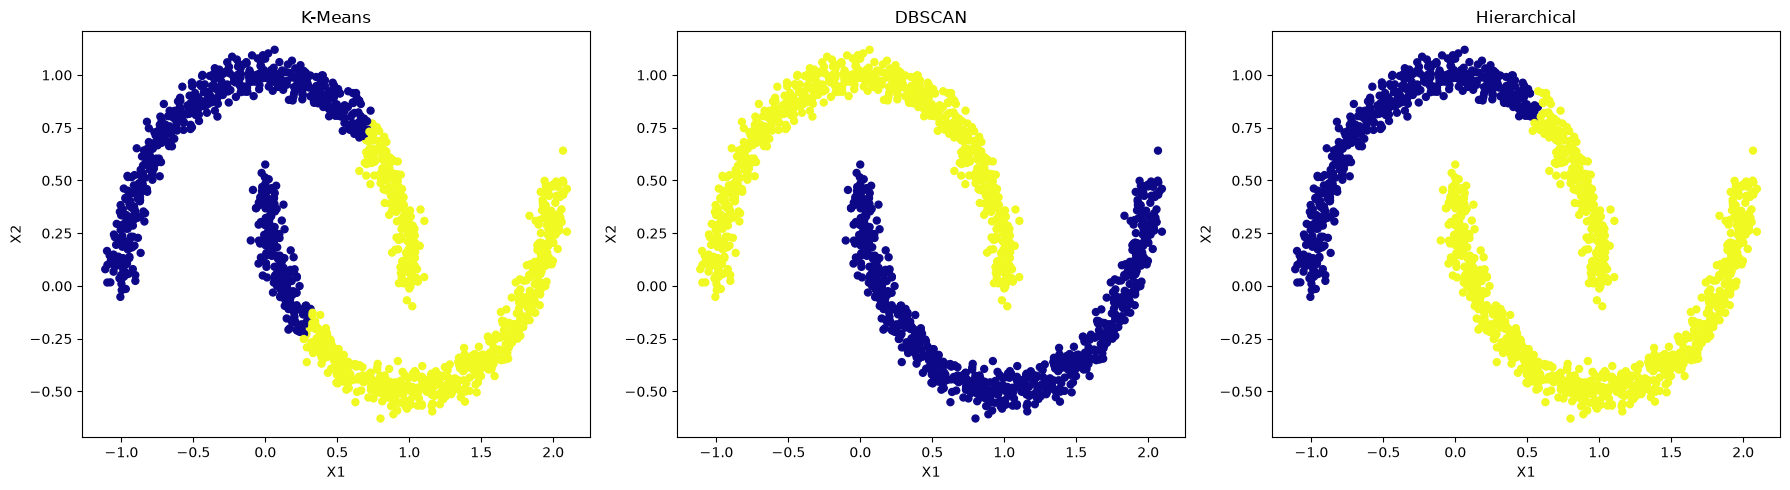

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
axes[0].scatter(
    X["X1"],
    X["X2"],
    c=kmeans_labels,
    cmap="plasma",
    s=25
)
axes[0].set_title("K-Means")

# DBSCAN
axes[1].scatter(
    X["X1"],
    X["X2"],
    c=dbscan_labels,
    cmap="plasma",
    s=25
)
axes[1].set_title("DBSCAN")

# Hierarchical
axes[2].scatter(
    X["X1"],
    X["X2"],
    c=hierarchical_labels,
    cmap="plasma",
    s=25
)
axes[2].set_title("Hierarchical")

for ax in axes:
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(135deg, #12002F, #2D0B59);
    border-radius: 14px;
    padding: 20px;
    color: white;
    border: 1px solid #C026FF;
    box-shadow: 0 0 12px #C026FF;
">

<h2 style="
    color: #F0ABFC;
    font-size: 24px;
    margin: 0 0 10px 0;
    text-shadow: 0 0 8px #C026FF;
">
🏆 Step 4 — Select the Best Clustering Method
</h2>

<p style="
    color: #E9D5FF;
    font-size: 17px;
    line-height: 1.8;
">
The final step is to determine which clustering method best represents
the structure of this dataset. The decision should be based on the shape
of the clusters, the presence of noise, and how naturally each algorithm
separates the data.
</p>

<p style="
    color: #F0ABFC;
    font-size: 17px;
    line-height: 1.8;
">
✍️ In the Markdown cell below, explain which method performed best and
why it is more suitable for this dataset.
</p>

</div>

<div style="
    background: linear-gradient(135deg, #12002F, #2D0B59);
    border-radius: 14px;
    padding: 22px;
    color: white;
    border: 1px solid #C026FF;
    box-shadow: 0 0 14px #C026FF;
    margin: 15px 0;
">

<h3 style="
    color: #F0ABFC;
    font-size: 25px;
    margin: 0 0 15px 0;
    text-shadow: 0 0 8px #C026FF;
">
📝 Final Comparison
</h3>

<p style="
    color: #E9D5FF;
    font-size: 17px;
    line-height: 1.8;
">
After comparing <strong style="color:#F0ABFC;">K-Means, DBSCAN, and Hierarchical Clustering</strong>,
the most suitable method for this dataset is
<strong style="color:#F0ABFC;">[write your choice here]</strong>.
</p>

<p style="
    color: #E9D5FF;
    font-size: 17px;
    line-height: 1.8;
">
The main reason is that the dataset contains a specific cluster shape that
may not be represented well by methods that assume simple, compact clusters.
</p>

<p style="
    color: #E9D5FF;
    font-size: 17px;
    line-height: 1.8;
">
<strong style="color:#F0ABFC;">DBSCAN</strong> is particularly useful when the dataset contains
irregularly shaped clusters or noise because it groups points according to
density rather than forcing every point into a cluster.
</p>

<div style="
    background: #3B0764;
    border-left: 5px solid #F0ABFC;
    padding: 13px 16px;
    border-radius: 10px;
    margin-top: 15px;
">

<p style="
    color: #F5D0FE;
    font-size: 17px;
    line-height: 1.8;
    margin: 0;
">
🏆 Based on the visual comparison and the clustering results,
<strong style="color:#FFFFFF;">[method name]</strong>
provides the most meaningful representation of the dataset.
</p>

</div>

</div>